<a href="https://colab.research.google.com/github/rushi-k-op/ML_DL/blob/main/RLandDL.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Reinforcement Learning And Deep Learning

# Reinforcement Learning: From Theory to Deep Q-Networks
**(Application: Inverted Pendulum (CartPole) Control)**

## Chapter 1: The Markov Decision Process (MDP) Framework
Reinforcement Learning (RL) problems are mathematically framed as **Markov Decision Processes (MDPs)**. An MDP provides a formal framework for modeling decision-making in situations where outcomes are partly random and partly under the control of a decision-maker (the **Agent**).

An MDP is defined by a tuple $\mathcal{M} = (\mathcal{S}, \mathcal{A}, \mathcal{P}, \mathcal{R}, \gamma)$:
* $\mathcal{S}$: The set of all possible **States** (the State Space).
* $\mathcal{A}$: The set of all possible **Actions** (the Action Space).
* $\mathcal{P}(s'|s, a)$: The transition probability of moving to state $s'$ given state $s$ and action $a$.
* $\mathcal{R}(s, a, s')$: The **Reward** function.
* $\gamma \in [0, 1)$: The **Discount Factor**, which determines the importance of future rewards.

### The Objective
The goal of the agent is to find an optimal policy $\pi^*$ that maximizes the expected cumulative discounted return, denoted as $G_t$, from any given time step $t$:

$$G_t = \sum_{k=0}^{\infty} \gamma^k R_{t+k+1}$$

### Our Environment: CartPole
We will apply this to the `CartPole-v1` environment, a classic control problem where a pole is attached by an un-actuated joint to a cart, which moves along a frictionless track. The system is controlled by applying a force of +1 or -1 to the cart.

Mathematically, our spaces look like this:
* **State Space ($\mathcal{S}$):** A continuous 4-dimensional vector $s \in \mathbb{R}^4$ representing:
    1. Cart Position ($x$)
    2. Cart Velocity ($\dot{x}$)
    3. Pole Angle ($\theta$)
    4. Pole Angular Velocity ($\dot{\theta}$)
* **Action Space ($\mathcal{A}$):** A discrete set of 2 actions $a \in \{0, 1\}$ (Push left, Push right).

Let's initialize the environment and inspect these spaces in code.

In [ ]:
# Install the necessary library if you haven't already
!pip install gymnasium pygame

import gymnasium as gym
import numpy as np

# Initialize the CartPole environment
env = gym.make('CartPole-v1')

# Extract and print the State (Observation) Space dimensions and bounds
print("--- State Space (S) ---")
print(f"Type: {env.observation_space}")
print(f"Maximum values (x, x_dot, theta, theta_dot): {env.observation_space.high}")
print(f"Minimum values (x, x_dot, theta, theta_dot): {env.observation_space.low}\n")

# Extract and print the Action Space dimensions
print("--- Action Space (A) ---")
print(f"Type: {env.action_space}")
print(f"Possible actions: 0 (Left), 1 (Right)\n")

# Reset the environment to get the initial state
initial_state, info = env.reset()
print(f"Initial State Vector (s_0): {initial_state}")

env.close()

--- State Space (S) ---
Type: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
Maximum values (x, x_dot, theta, theta_dot): [4.8               inf 0.41887903        inf]
Minimum values (x, x_dot, theta, theta_dot): [-4.8               -inf -0.41887903        -inf]

--- Action Space (A) ---
Type: Discrete(2)
Possible actions: 0 (Left), 1 (Right)

Initial State Vector (s_0): [ 0.0162025  -0.03200865 -0.01649868 -0.01611054]


## Chapter 2: Value Functions and The Bellman Equation

To make optimal decisions, the agent needs a way to evaluate "how good" it is to be in a certain state, or how good it is to take a specific action in that state. We define two mathematical functions for this:

**1. The State-Value Function, $V^\pi(s)$:**
The expected return when starting in state $s$ and following policy $\pi$ thereafter.
$$V^\pi(s) = \mathbb{E}_\pi [ G_t | S_t = s ]$$

**2. The Action-Value Function, $Q^\pi(s,a)$:**
The expected return when starting in state $s$, taking action $a$, and then following policy $\pi$.
$$Q^\pi(s,a) = \mathbb{E}_\pi [ G_t | S_t = s, A_t = a ]$$

### The Bellman Optimality Equation
The core idea of RL is that we can define these values recursively. The value of taking action $a$ in state $s$ is the immediate reward we get, plus the discounted maximum value of the *next* state. This is the **Bellman Optimality Equation for Q-values**:

$$Q^*(s,a) = \mathbb{E} \left[ R_{t+1} + \gamma \max_{a'} Q^*(S_{t+1}, a') \mid S_t=s, A_t=a \right]$$

If the agent can perfectly solve this equation, it simply looks at its current state and picks the action with the highest $Q$-value.

### Baseline: A Policy Without Value Functions
Before we implement an algorithm to solve the Bellman equation, let's see what happens if our policy $\pi$ simply picks actions at random without considering any future value.

In [ ]:
import gymnasium as gym

# Initialize the environment
env = gym.make('CartPole-v1')
state, info = env.reset()

done = False
total_reward = 0
step_count = 0

# Run a single episode with a completely random policy
while not done:
    # Sample a random action from the action space (0 or 1)
    action = env.action_space.sample()

    # The environment processes the action and returns the next step
    next_state, reward, terminated, truncated, info = env.step(action)

    total_reward += reward
    step_count += 1

    # The episode ends if the pole falls (terminated) or hits the time limit (truncated)
    done = terminated or truncated

print(f"Random Agent Performance:")
print(f"Total Steps Survived: {step_count}")
print(f"Total Reward Accumulated: {total_reward}")

env.close()

# Note: The CartPole environment considers the problem "solved" if the agent
# can survive for 500 steps. A random agent usually fails in 10-25 steps.

Random Agent Performance:
Total Steps Survived: 17
Total Reward Accumulated: 17.0


## Chapter 3: Tabular Q-Learning (Temporal Difference Learning)

To solve the Bellman Optimality Equation without knowing the environment's exact transition dynamics ($\mathcal{P}$), we can use a model-free approach called **Q-Learning**. This is a form of Temporal Difference (TD) learning.

### The Q-Learning Update Rule
Instead of computing the exact expected value, Q-Learning updates its estimates step-by-step based on the difference between the old estimate and a new, noisy estimate (the TD target). The update rule applied after taking action $A_t$ in state $S_t$ and observing reward $R_{t+1}$ and next state $S_{t+1}$ is:

$$Q(S_t, A_t) \leftarrow Q(S_t, A_t) + \alpha \left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$$

Where:
* $\alpha \in (0,1]$ is the **Learning Rate**.
* $\left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) \right]$ is the **TD Target** (our new guess).
* $\left[ R_{t+1} + \gamma \max_{a} Q(S_{t+1}, a) - Q(S_t, A_t) \right]$ is the **TD Error**.

### Exploration vs. Exploitation ($\epsilon$-greedy)
To learn the optimal Q-values, the agent must explore the environment. If it only exploits its current knowledge, it might get stuck in a sub-optimal policy. We manage this using an **$\epsilon$-greedy policy**:
* With probability $1 - \epsilon$: **Exploit** by choosing $\arg\max_a Q(S_t, a)$.
* With probability $\epsilon$: **Explore** by choosing a random action $a \in \mathcal{A}$.

### The Continuous State Problem (Discretization)
Because $s \in \mathbb{R}^4$, we have infinite possible states. A Q-table cannot hold infinite rows. To force tabular Q-learning to work, we must discretize the state space, mapping ranges of continuous values into discrete "bins".

Let's implement this and plot the learning curve.

Training Tabular Q-Learning Agent...
Episode: 1000 | Average Reward (last 100): 40.35
Episode: 2000 | Average Reward (last 100): 90.26
Episode: 3000 | Average Reward (last 100): 107.9
Episode: 4000 | Average Reward (last 100): 124.16
Episode: 5000 | Average Reward (last 100): 131.82


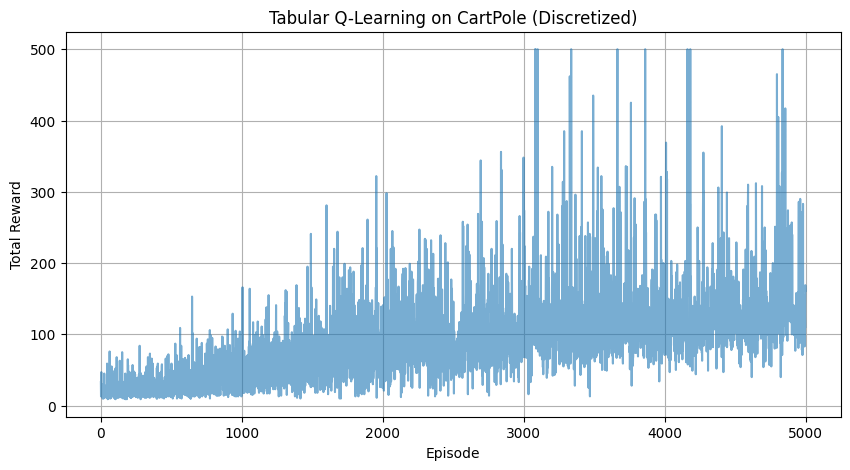

In [ ]:
import gymnasium as gym
import numpy as np
import matplotlib.pyplot as plt

# 1. Discretization Setup
env = gym.make('CartPole-v1')

# Define the number of bins per state variable
num_bins = 20

# We set manual bounds for the velocity variables because 'inf' cannot be binned
bins = [
    np.linspace(-4.8, 4.8, num_bins),      # Cart Position
    np.linspace(-4, 4, num_bins),          # Cart Velocity
    np.linspace(-0.418, 0.418, num_bins),  # Pole Angle
    np.linspace(-4, 4, num_bins)           # Pole Angular Velocity
]

def discretize_state(state):
    """Maps a continuous state vector to a discrete tuple of bin indices."""
    discrete_state = []
    for i in range(len(state)):
        discrete_state.append(np.digitize(state[i], bins[i]) - 1)
    return tuple(discrete_state)

# 2. Initialize Q-Table
# Shape: (20, 20, 20, 20, 2) initialized to zeros
q_table = np.zeros((num_bins, num_bins, num_bins, num_bins, env.action_space.n))

# 3. Hyperparameters
alpha = 0.1          # Learning Rate
gamma = 0.95         # Discount Factor
epsilon = 1.0        # Initial Exploration Rate
epsilon_decay = 0.9995
epsilon_min = 0.01
episodes = 5000

rewards_history = []

# 4. Training Loop
print("Training Tabular Q-Learning Agent...")

for episode in range(episodes):
    state, _ = env.reset()
    discrete_state = discretize_state(state)
    done = False
    total_reward = 0

    while not done:
        # Epsilon-greedy action selection
        if np.random.random() < epsilon:
            action = env.action_space.sample()  # Explore
        else:
            action = np.argmax(q_table[discrete_state])  # Exploit

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated
        next_discrete_state = discretize_state(next_state)

        # Q-Learning Update
        if not done:
            best_next_action = np.argmax(q_table[next_discrete_state])
            td_target = reward + gamma * q_table[next_discrete_state][best_next_action]
            td_error = td_target - q_table[discrete_state][action]
            q_table[discrete_state][action] += alpha * td_error

        discrete_state = next_discrete_state
        total_reward += reward

    # Decay epsilon
    epsilon = max(epsilon_min, epsilon * epsilon_decay)
    rewards_history.append(total_reward)

    if (episode + 1) % 1000 == 0:
        print(f"Episode: {episode + 1} | Average Reward (last 100): {np.mean(rewards_history[-100:])}")

env.close()

# 5. Plotting the Learning Curve
plt.figure(figsize=(10, 5))
plt.plot(rewards_history, alpha=0.6)
plt.title('Tabular Q-Learning on CartPole (Discretized)')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.grid(True)
plt.show()

### Analyzing the Results: The Limits of Tabular Learning

If you look at the training curve above, it tells a very specific story about how our agent is learning:

1. **Learning is Happening:** Unlike the random agent that failed in 17 steps, this agent quickly learns to survive much longer, often pushing past 100 or 200 steps. The Q-table is definitely capturing useful information.
2. **High Variance and Instability:** The graph is incredibly jagged. The agent might perfectly balance the pole for 500 steps in one episode, but completely fail at 80 steps in the next. It never smoothly converges to a stable, perfect policy.

**Why does this happen? The Discretization Flaw**
This instability is the direct result of forcing continuous numbers into discrete bins. Imagine the pole is leaning right at an angle of `0.15` radians. The agent looks at its discrete state bucket, which covers everything from `0.1` to `0.2` radians, and takes an action. Later, the pole leans at `0.19` radians. It is in the exact same bucket, so the agent is forced to take the exact same action—but the physical momentum is entirely different, causing the pole to fall.

By putting continuous physics into discrete buckets, we lose the fine motor control required for smooth robotic operation.

#**The Transition to Deep Learning**
To solve continuous control problems natively without losing precision, we cannot use a finite table. We need a mathematical function that can take the exact continuous state vector as an input and output the exact Q-values. This is where we replace the Q-table with a **Deep Neural Network**, leading us to the Deep Q-Network (DQN) algorithm.

## Chapter 4: Function Approximation and Deep Q-Networks (DQN)

As we saw, tabular methods struggle with continuous state spaces like $\mathcal{S} \in \mathbb{R}^4$. Discretization discards critical precision. To solve this, we move from finding exact values in a table to **Approximating** the values using a mathematical function.

We introduce a parametric function, specifically a Deep Neural Network, with weights $\theta$. Our goal is to approximate the optimal action-value function:
$$Q(s,a;\theta) \approx Q^*(s,a)$$

Instead of updating a single table cell, we now update the weights $\theta$ of the neural network using Stochastic Gradient Descent (SGD) to minimize the Temporal Difference (TD) error.

### The Objective (Loss) Function
We want to minimize the Mean Squared Error between our current Q-value prediction and our TD Target. The loss function is defined as:

$$L(\theta) = \mathbb{E} \left[ \left( R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a'; \theta^-) - Q(S_t, A_t; \theta) \right)^2 \right]$$

There are two major additions in this formula that make Deep Q-Networks stable:

**1. The Target Network ($\theta^-$)**
If we use the same network to calculate both the predicted Q-value and the Target Q-value, the target moves every time we update the weights. It is like a dog chasing its own tail. To fix this, we use a separate **Target Network** with weights $\theta^-$. This network is kept frozen and only updated to match the main network ($\theta$) periodically.

**2. Experience Replay ($\mathbb{E}$)**
Neural networks forget past experiences quickly and perform poorly on highly correlated, sequential data (like frames of a simulation). We solve this by storing every step as a transition tuple $(S_t, A_t, R_{t+1}, S_{t+1}, \text{done})$ in an **Experience Replay Buffer**. We then train the network by drawing random mini-batches from this buffer, breaking the correlation and smoothing the learning process.

Let's implement the Neural Network and the Replay Buffer using PyTorch.

In [ ]:
# Install PyTorch if not already available in the environment
!pip install torch

import torch
import torch.nn as nn
import torch.nn.functional as F
import random
from collections import deque
import numpy as np

# 1. Define the Neural Network Architecture
class DQN(nn.Module):
    def __init__(self, state_dim, action_dim):
        super(DQN, self).__init__()
        # A simple Multi-Layer Perceptron (MLP)
        self.fc1 = nn.Linear(state_dim, 64)
        self.fc2 = nn.Linear(64, 64)
        self.out = nn.Linear(64, action_dim)

    def forward(self, x):
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        return self.out(x) # Outputs Q-values for all actions

# 2. Define the Experience Replay Buffer
class ReplayBuffer:
    def __init__(self, capacity):
        # deque automatically removes oldest elements when full
        self.buffer = deque(maxlen=capacity)

    def push(self, state, action, reward, next_state, done):
        """Saves a transition to the buffer."""
        self.buffer.append((state, action, reward, next_state, done))

    def sample(self, batch_size):
        """Returns a random mini-batch of transitions."""
        transitions = random.sample(self.buffer, batch_size)

        # Unzip the batch into separate arrays
        states, actions, rewards, next_states, dones = zip(*transitions)

        return (np.array(states), np.array(actions), np.array(rewards),
                np.array(next_states), np.array(dones))

    def __len__(self):
        return len(self.buffer)

# Test the setup
state_dim = 4  # CartPole state space
action_dim = 2 # CartPole action space

# Initialize network and buffer
policy_net = DQN(state_dim, action_dim)
memory = ReplayBuffer(capacity=10000)

print(f"Neural Network Architecture:\n{policy_net}")
print(f"Replay Buffer Initialized with capacity: {memory.buffer.maxlen}")

Neural Network Architecture:
DQN(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=64, bias=True)
  (out): Linear(in_features=64, out_features=2, bias=True)
)
Replay Buffer Initialized with capacity: 10000


## Chapter 5: Training the Deep Q-Network

We now bring the theory and architecture together into the main training loop. The DQN algorithm follows these specific steps for every episode:

1. **Action Selection:** The agent observes the continuous state $S_t$ and selects action $A_t$ using an $\epsilon$-greedy policy. To exploit, it passes $S_t$ through the main network and chooses $\arg\max_a Q(S_t, a; \theta)$.
2. **Environment Step:** The agent executes $A_t$, receiving reward $R_{t+1}$ and observing the next state $S_{t+1}$.
3. **Store Experience:** The transition $(S_t, A_t, R_{t+1}, S_{t+1}, \text{done})$ is pushed into the Replay Buffer.
4. **Sample and Learn (Gradient Descent):** * Once the buffer has enough data, we sample a random mini-batch of size $N$.
    * We compute the predicted Q-values using the main network ($\theta$).
    * We compute the Target Q-values using the frozen target network ($\theta^-$): $$y_i = R_{t+1} + \gamma \max_{a'} Q(S_{t+1}, a'; \theta^-)$$
    * *Note: If the state is terminal (the pole fell), the target is strictly the immediate reward: $y_i = R_{t+1}$.*
    * We update the weights $\theta$ by minimizing the Mean Squared Error (MSE) loss using the Adam optimizer.
5. **Target Update:** Every $C$ episodes, we synchronize the networks by copying the weights: $\theta^- \leftarrow \theta$.

Let's implement the training loop.

Training Deep Q-Network. This may take 1-3 minutes...
Episode: 50 | Average Reward (last 50): 25.7
Episode: 100 | Average Reward (last 50): 48.54
Episode: 150 | Average Reward (last 50): 76.38
Episode: 200 | Average Reward (last 50): 71.44
Episode: 250 | Average Reward (last 50): 40.78
Episode: 300 | Average Reward (last 50): 43.34
Episode: 350 | Average Reward (last 50): 46.48
Episode: 400 | Average Reward (last 50): 60.92
Episode: 450 | Average Reward (last 50): 75.2
Episode: 500 | Average Reward (last 50): 63.46


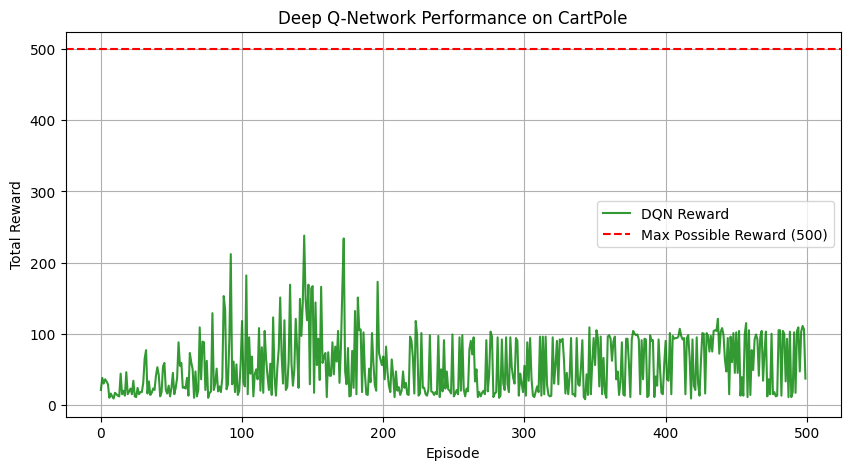

In [ ]:
import gymnasium as gym
import torch.optim as optim
import matplotlib.pyplot as plt

# 1. Hyperparameters
BATCH_SIZE = 64
GAMMA = 0.99
EPSILON_START = 1.0
EPSILON_END = 0.01
EPSILON_DECAY = 0.995
LEARNING_RATE = 1e-3
TARGET_UPDATE = 10 # Update target network every 10 episodes
EPISODES = 500

# 2. Setup Environment and Networks
env = gym.make('CartPole-v1')
state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n

policy_net = DQN(state_dim, action_dim)
target_net = DQN(state_dim, action_dim)
target_net.load_state_dict(policy_net.state_dict()) # Clone initial weights
target_net.eval() # Target network is only used for inference

optimizer = optim.Adam(policy_net.parameters(), lr=LEARNING_RATE)
memory = ReplayBuffer(10000)

epsilon = EPSILON_START
dqn_rewards = []

print("Training Deep Q-Network. This may take 1-3 minutes...")

# 3. Main Training Loop
for episode in range(EPISODES):
    state, _ = env.reset()
    state = torch.tensor(state, dtype=torch.float32).unsqueeze(0)
    total_reward = 0
    done = False

    while not done:
        # Epsilon-greedy action selection
        if random.random() < epsilon:
            action = env.action_space.sample()
        else:
            with torch.no_grad():
                action = policy_net(state).argmax().item()

        # Step the environment
        next_state, reward, terminated, truncated, _ = env.step(action)
        done = terminated or truncated

        # Convert to tensors for storage
        next_state_tensor = torch.tensor(next_state, dtype=torch.float32).unsqueeze(0)

        # Store in replay buffer
        memory.push(state.numpy(), action, reward, next_state_tensor.numpy(), done)
        state = next_state_tensor
        total_reward += reward

        # Optimization Step (Learn from memory)
        if len(memory) >= BATCH_SIZE:
            states, actions, rewards, next_states, dones = memory.sample(BATCH_SIZE)

            # Convert arrays to PyTorch tensors
            states_t = torch.tensor(states, dtype=torch.float32).squeeze(1)
            actions_t = torch.tensor(actions, dtype=torch.int64).unsqueeze(1)
            rewards_t = torch.tensor(rewards, dtype=torch.float32).unsqueeze(1)
            next_states_t = torch.tensor(next_states, dtype=torch.float32).squeeze(1)
            dones_t = torch.tensor(dones, dtype=torch.float32).unsqueeze(1)

            # Compute current Q values (Q(s, a))
            q_values = policy_net(states_t).gather(1, actions_t)

            # Compute next maximum Q values from Target Network (max Q(s', a'))
            with torch.no_grad():
                next_q_values = target_net(next_states_t).max(1)[0].unsqueeze(1)

            # Compute expected Q values (TD Target)
            # If done == 1, (1 - dones_t) becomes 0, zeroing out the future reward
            expected_q_values = rewards_t + GAMMA * next_q_values * (1 - dones_t)

            # Compute loss and perform backpropagation
            #loss = nn.MSELoss()(q_values, expected_q_values)
            loss = nn.SmoothL1Loss()(q_values, expected_q_values)   #replaced from MSELoss
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

    # End of episode tasks
    dqn_rewards.append(total_reward)
    epsilon = max(EPSILON_END, epsilon * EPSILON_DECAY)

    # Update Target Network
    if episode % TARGET_UPDATE == 0:
        target_net.load_state_dict(policy_net.state_dict())

    if (episode + 1) % 50 == 0:
        print(f"Episode: {episode + 1} | Average Reward (last 50): {np.mean(dqn_rewards[-50:])}")

env.close()

# 4. Plot Results
plt.figure(figsize=(10, 5))
plt.plot(dqn_rewards, label='DQN Reward', color='green', alpha=0.8)
plt.axhline(y=500, color='r', linestyle='--', label='Max Possible Reward (500)')
plt.title('Deep Q-Network Performance on CartPole')
plt.xlabel('Episode')
plt.ylabel('Total Reward')
plt.legend()
plt.grid(True)
plt.show()